In [2]:
from math import log1p

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [3]:
df=pd.read_csv('ai_ds_job_salaries_2026.csv')
df.head(3)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8


In [4]:
pd.set_option('display.max_columns',None)
df.head(3)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,primary_language,has_ml_in_title,manages_people,team_size,certifications_count,weekly_hours,uses_ai_tools_daily,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,Python,False,True,5,0,48.0,True,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,SQL,True,False,6,1,41.6,False,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,Python,True,False,4,1,55.1,True,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8


In [5]:
numerical_col=df.select_dtypes(include='number')

<Axes: >

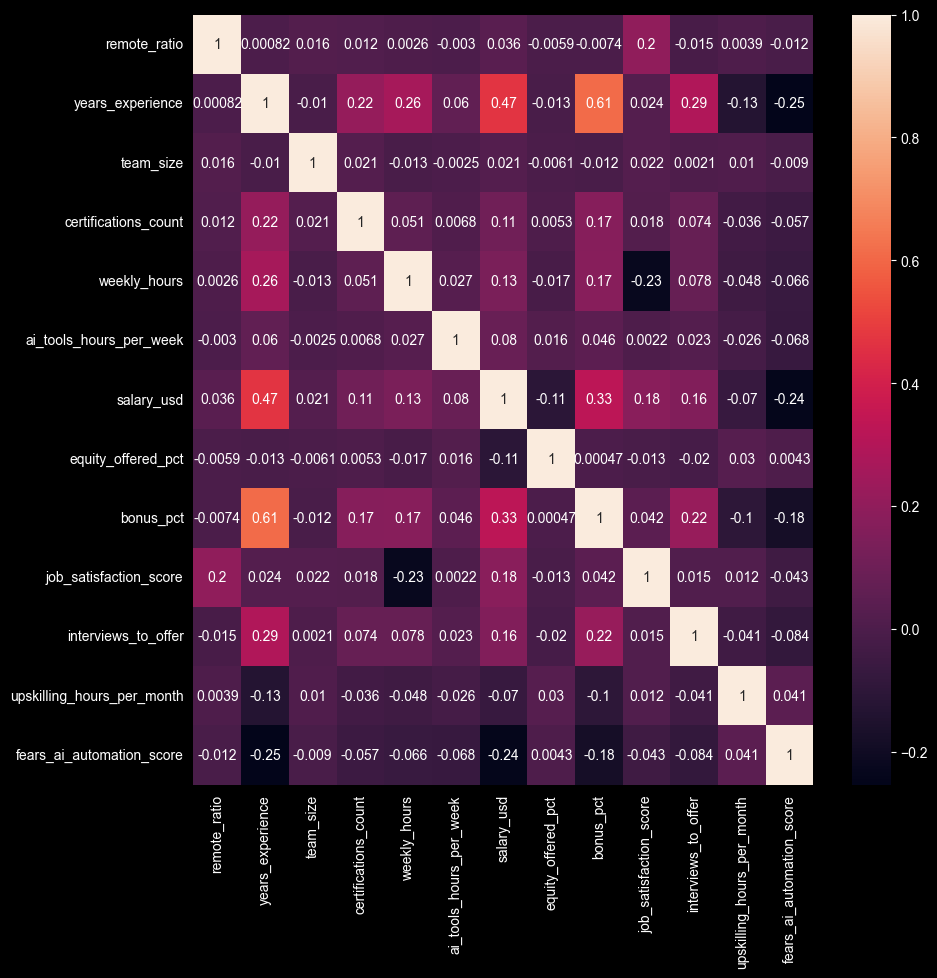

In [6]:
plt.figure(figsize=(10,10),dpi=100)
sns.heatmap(numerical_col.corr(),annot=True)

In [7]:
df.isnull().sum()

job_title                     0
experience_level              0
employment_type               0
company_size                  0
company_location              0
employee_residence            0
industry                      0
remote_ratio                  0
years_experience              0
education_level               0
primary_language              0
has_ml_in_title               0
manages_people                0
team_size                     0
certifications_count          0
weekly_hours                  0
uses_ai_tools_daily           0
ai_tools_hours_per_week       0
salary_currency               0
salary_usd                    0
equity_offered_pct            0
bonus_pct                     0
job_satisfaction_score        0
interviews_to_offer           0
switched_jobs_last_year       0
upskilling_hours_per_month    0
fears_ai_automation_score     0
dtype: int64

In [8]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'remote_ratio',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'team_size',
       'certifications_count', 'weekly_hours', 'uses_ai_tools_daily',
       'ai_tools_hours_per_week', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'upskilling_hours_per_month', 'fears_ai_automation_score'],
      dtype='object')

In [9]:
df_cleaned=df.drop(['upskilling_hours_per_month','ai_tools_hours_per_week','team_size','remote_ratio'],axis=1)

In [37]:
cat_col=df_cleaned.select_dtypes(exclude='number')

In [38]:
cat_col.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'education_level',
       'primary_language', 'has_ml_in_title', 'manages_people',
       'uses_ai_tools_daily', 'salary_currency', 'switched_jobs_last_year'],
      dtype='object')

In [39]:
df_cleaned.describe()

,years_experience,certifications_count,weekly_hours,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,fears_ai_automation_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,8.361440,1.820400,44.345400,98605.406200,0.139020,10.802720,6.685320,5.230800,4.846080
std,4.820808,1.344212,6.142761,55369.310473,0.184243,5.152959,1.364302,2.412695,1.725924
min,0.000000,0.000000,24.400000,12000.000000,0.000000,0.000000,1.100000,1.000000,1.000000
25%,4.800000,1.000000,40.100000,55592.750000,0.017000,7.100000,5.800000,3.000000,3.700000
50%,8.100000,2.000000,44.400000,90572.000000,0.072000,10.600000,6.700000,5.000000,4.800000
75%,11.500000,3.000000,48.500000,129657.750000,0.175000,14.200000,7.600000,7.000000,6.000000
max,23.700000,8.000000,67.300000,372347.000000,1.264000,30.800000,10.000000,16.000000,10.000000


In [40]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   job_title                  5000 non-null   object 
 1   experience_level           5000 non-null   object 
 2   employment_type            5000 non-null   object 
 3   company_size               5000 non-null   object 
 4   company_location           5000 non-null   object 
 5   employee_residence         5000 non-null   object 
 6   industry                   5000 non-null   object 
 7   years_experience           5000 non-null   float64
 8   education_level            5000 non-null   object 
 9   primary_language           5000 non-null   object 
 10  has_ml_in_title            5000 non-null   bool   
 11  manages_people             5000 non-null   bool   
 12  certifications_count       5000 non-null   int64  
 13  weekly_hours               5000 non-null   float

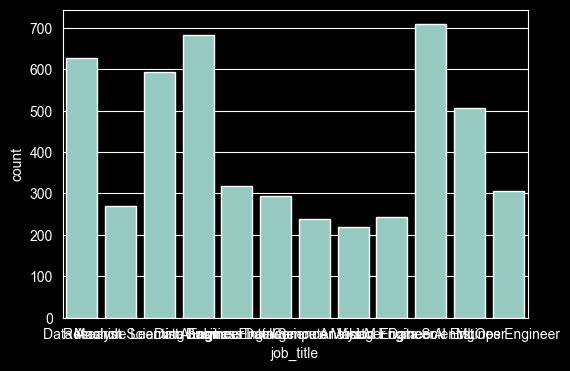

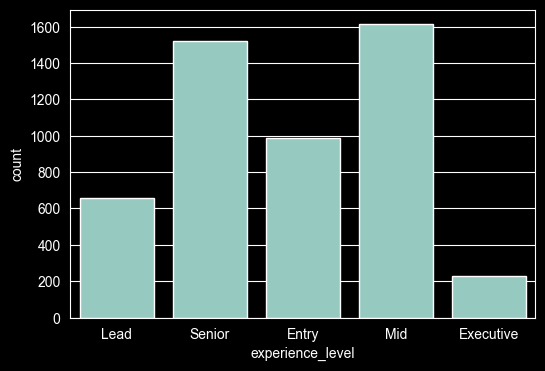

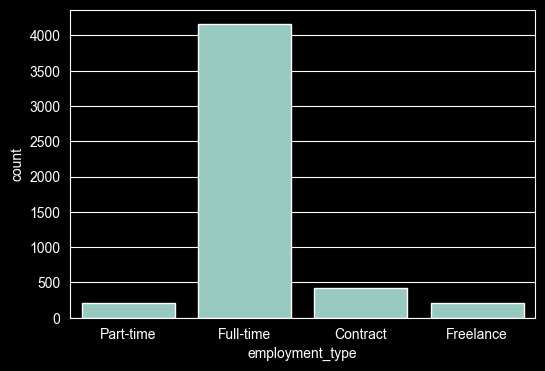

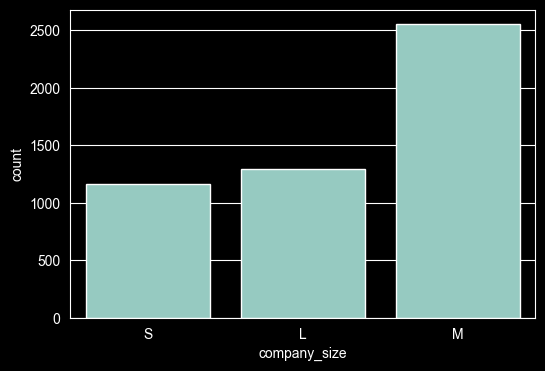

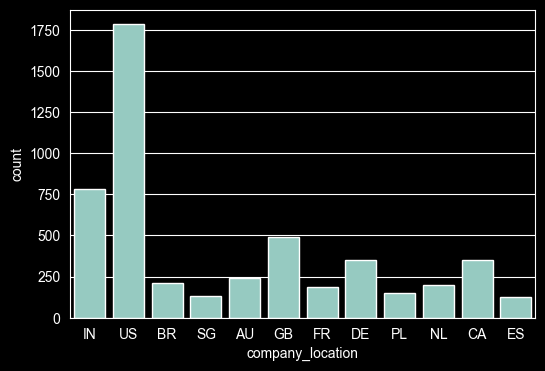

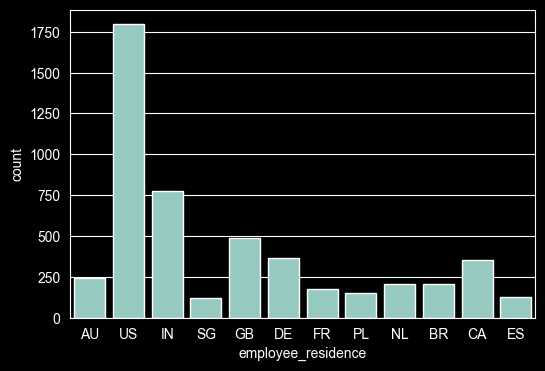

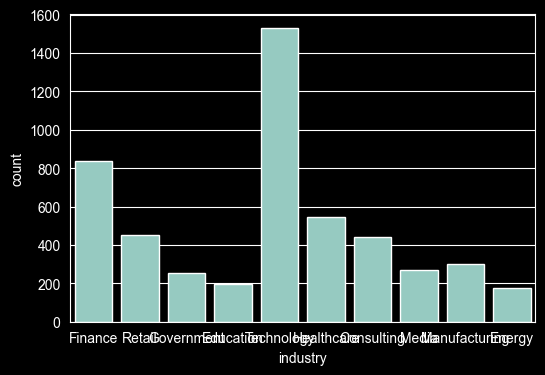

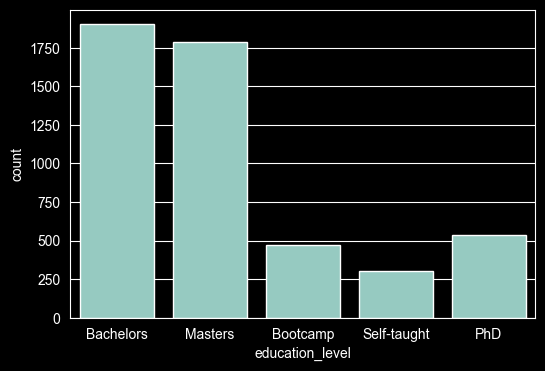

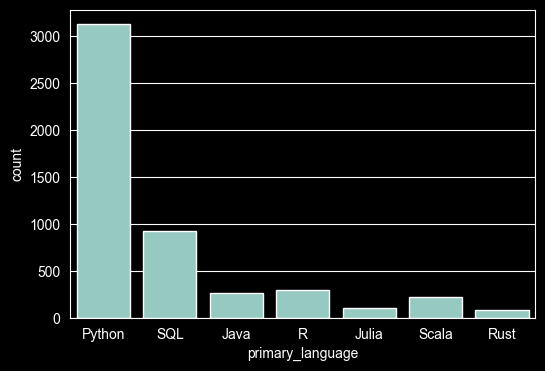

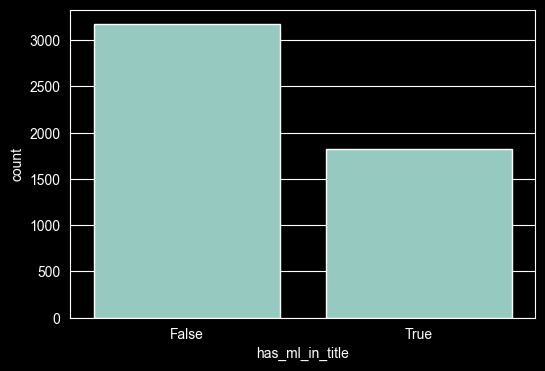

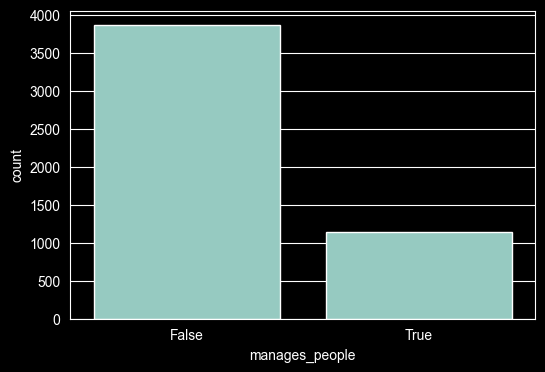

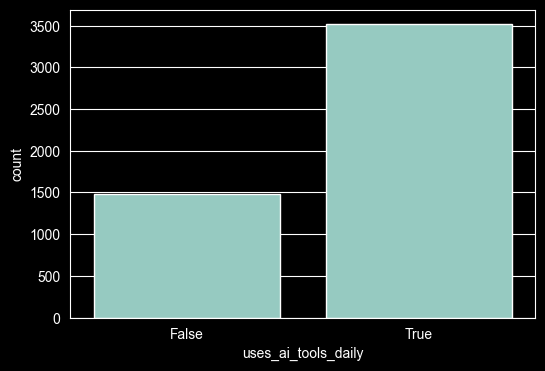

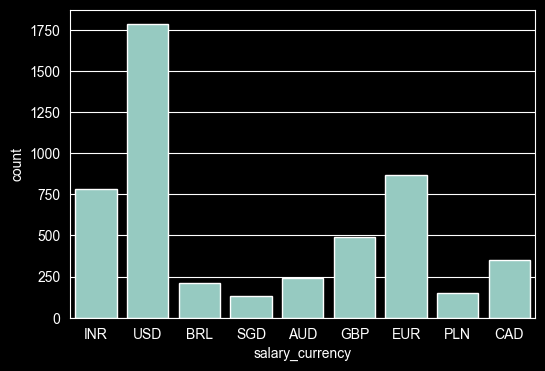

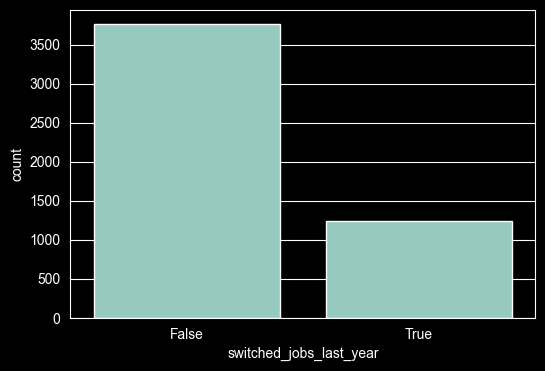

In [41]:
for col in cat_col:
    plt.figure(figsize=(6,4),dpi=100)
    sns.countplot(data=df_cleaned,x=col)

In [42]:
df_cleaned['job_title'].value_counts().count()

np.int64(12)

<Figure size 2000x2000 with 0 Axes>

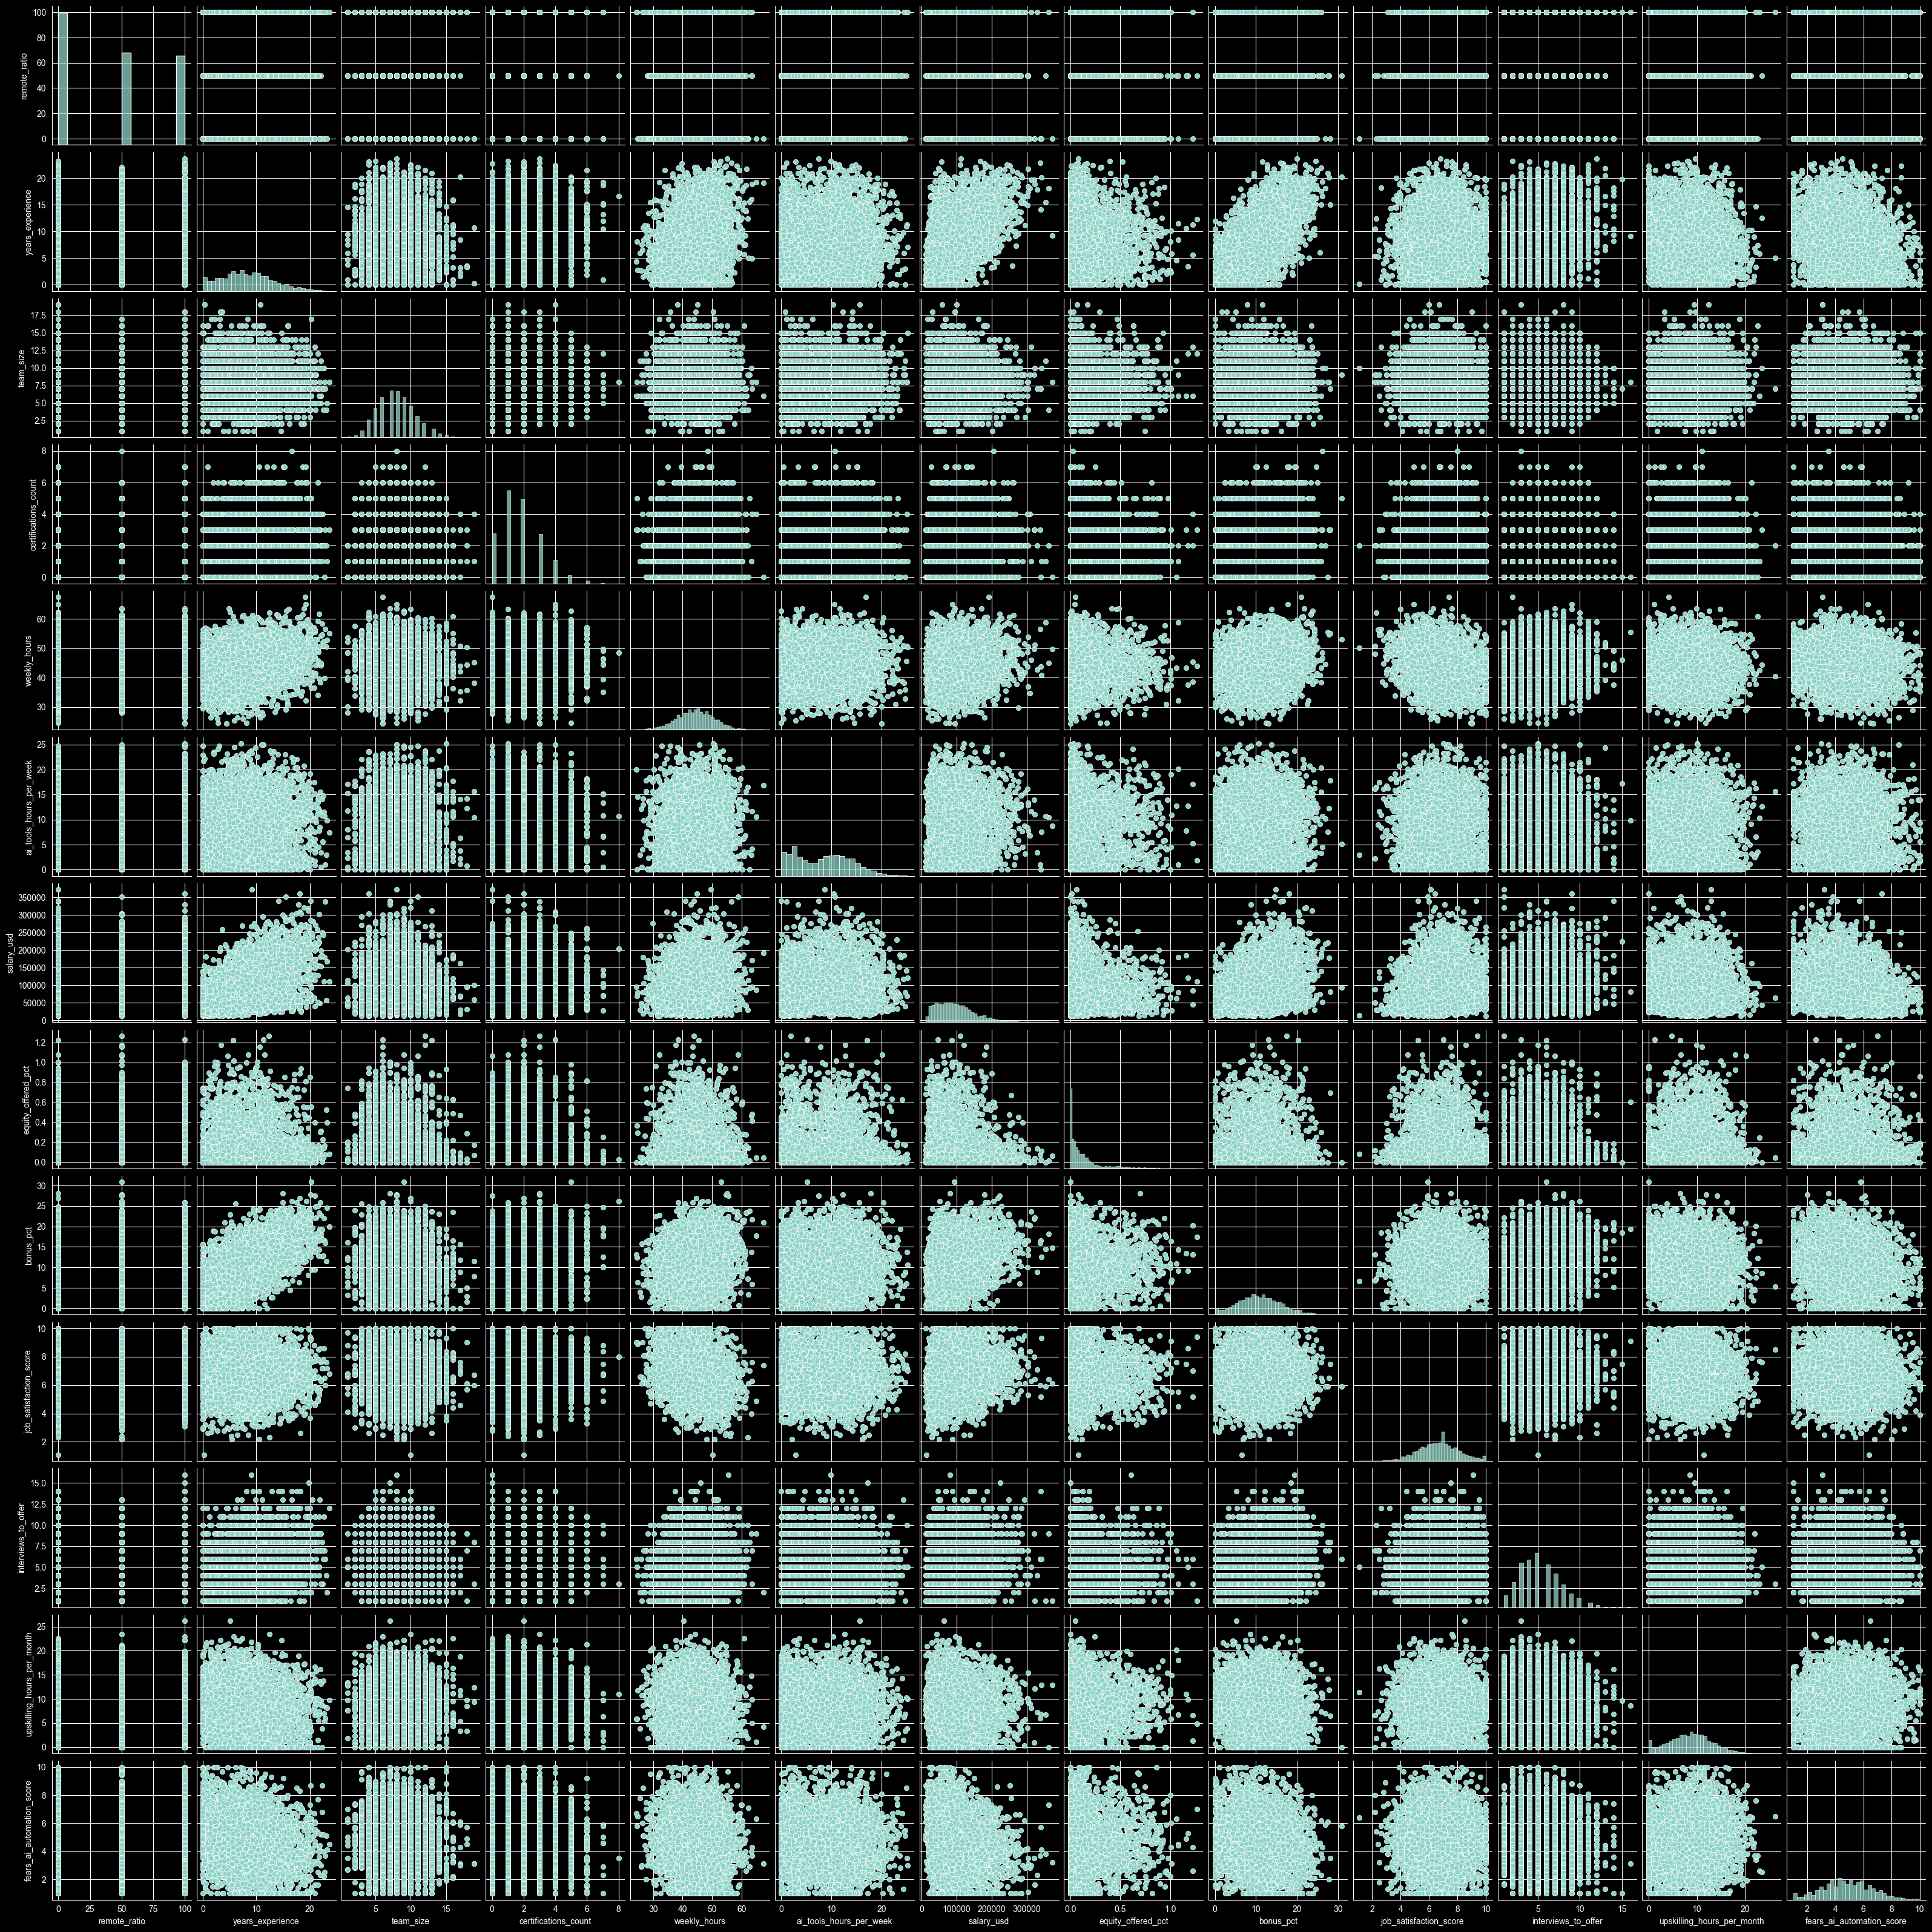

In [43]:
plt.figure(figsize=(20,20),dpi=100)
sns.pairplot(numerical_col)

In [44]:
df_cleaned.head(3)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,years_experience,education_level,primary_language,has_ml_in_title,manages_people,certifications_count,weekly_hours,uses_ai_tools_daily,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,14.4,Bachelors,Python,False,True,0,48.0,True,INR,23844,0.505,11.6,5.5,8,True,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,7.6,Masters,SQL,True,False,1,41.6,False,USD,170132,0.054,2.9,7.0,3,False,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0.0,Bootcamp,Python,True,False,1,55.1,True,USD,83059,0.191,7.5,5.9,1,False,6.8


In [45]:
pd.set_option('display.max_columns', None)
df_cleaned.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,years_experience,education_level,primary_language,has_ml_in_title,manages_people,certifications_count,weekly_hours,uses_ai_tools_daily,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,14.4,Bachelors,Python,False,True,0,48.0,True,INR,23844,0.505,11.6,5.5,8,True,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,7.6,Masters,SQL,True,False,1,41.6,False,USD,170132,0.054,2.9,7.0,3,False,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0.0,Bootcamp,Python,True,False,1,55.1,True,USD,83059,0.191,7.5,5.9,1,False,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,9.7,Masters,Java,False,False,2,41.1,True,BRL,29531,0.102,9.3,5.6,5,False,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,3.2,Bachelors,Python,False,False,2,48.2,False,USD,70105,0.064,10.6,4.6,4,False,5.1


In [46]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, FunctionTransformer

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
numerical_col.skew()

remote_ratio                  0.262652
years_experience              0.364006
team_size                     0.360627
certifications_count          0.722400
weekly_hours                 -0.027557
ai_tools_hours_per_week       0.266549
salary_usd                    0.907682
equity_offered_pct            2.184588
bonus_pct                     0.182433
job_satisfaction_score        0.002830
interviews_to_offer           0.556307
upskilling_hours_per_month    0.122447
fears_ai_automation_score     0.076280
dtype: float64

In [49]:
X=df_cleaned.drop('salary_usd',axis=1)
y=df_cleaned['salary_usd']

In [50]:
df_cleaned.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'certifications_count',
       'weekly_hours', 'uses_ai_tools_daily', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'fears_ai_automation_score'],
      dtype='object')

In [51]:
df_cleaned.shape

(5000, 23)

In [52]:
ordinal_col=['experience_level','company_size']
one_hot_col=['job_title','employment_type','company_location','employee_residence','industry','education_level','primary_language','salary_currency']
type_conversion_col=['has_ml_in_title','manages_people','uses_ai_tools_daily','switched_jobs_last_year','fears_ai_automation_score']
skewed_col=['equity_offered_pct','interviews_to_offer']
normal_col=['years_experience','certifications_count','weekly_hours','bonus_pct','job_satisfaction_score']

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
for col in type_conversion_col:
    X[col]=X[col].astype('int')

In [56]:
X.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,years_experience,education_level,primary_language,has_ml_in_title,manages_people,certifications_count,weekly_hours,uses_ai_tools_daily,salary_currency,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,14.4,Bachelors,Python,0,1,0,48.0,1,INR,0.505,11.6,5.5,8,1,7
1,Research Scientist,Senior,Full-time,L,US,US,Retail,7.6,Masters,SQL,1,0,1,41.6,0,USD,0.054,2.9,7.0,3,0,5
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0.0,Bootcamp,Python,1,0,1,55.1,1,USD,0.191,7.5,5.9,1,0,6
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,9.7,Masters,Java,0,0,2,41.1,1,BRL,0.102,9.3,5.6,5,0,5
4,Data Engineer,Mid,Full-time,M,US,US,Education,3.2,Bachelors,Python,0,0,2,48.2,0,USD,0.064,10.6,4.6,4,0,5


In [57]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [59]:
from sklearn.pipeline import Pipeline

In [60]:
from sklearn.compose import ColumnTransformer

In [61]:
from sklearn.preprocessing import FunctionTransformer

In [63]:
ordinal_pipeline=Pipeline([
    ('ordinal_encoding',OrdinalEncoder(categories=[['Entry','Mid','Lead','Senior','Executive'],['S','M','L']]))
])
one_hot_pipeline=Pipeline([
    ('one_hot',OneHotEncoder())
])
skewed_pipeline=Pipeline([
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scalar',StandardScaler())
])
normal_pipeline=Pipeline([
    ('scalar',StandardScaler())
])

In [64]:
preprocessor=ColumnTransformer(transformers=[
    ('skew_process',skewed_pipeline,skewed_col),
    ('ordinal_process',ordinal_pipeline,ordinal_col),
    ('one_hot_process',one_hot_pipeline,one_hot_col),
    ('normal_process',normal_pipeline,normal_col)
])

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor

In [66]:
linear_model=Pipeline([
    ('preprocessor',preprocessor),
    ('linear_mode',LinearRegression())
])

In [67]:
linear_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('linear_mode', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_process', ...), ('ordinal_process', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output 

In [68]:
y_pred_test=linear_model.predict(X_test)

In [69]:
from sklearn.metrics import r2_score

In [70]:
print(r2_score(y_pred_test,y_test))

0.7289195353613633


In [71]:
y_pred_train=linear_model.predict(X_train)
print(r2_score(y_pred_train,y_train))

0.7570909545908071


**RandomForest_model**

In [72]:
rf_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('rf_model',RandomForestRegressor(n_estimators=100))
])

In [73]:
rf_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_process', ...), ('ordinal_process', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [74]:
y_pred_random_test=rf_pipeline.predict(X_test)
print(r2_score(y_test,y_pred_random_test))

0.7724860091616443


In [75]:
y_pred_random_train=rf_pipeline.predict(X_train)
print(r2_score(y_train,y_pred_random_train))

0.9714134241639732


**my randomregressor_model is overfitting**

In [76]:
from xgboost import XGBRegressor

In [77]:
xg_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('xg_model',XGBRegressor(n_estimators=100)),
])

In [78]:
xg_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('xg_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_process', ...), ('ordinal_process', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of 

In [79]:
y_pred_xg_test=xg_pipeline.predict(X_test)
print(r2_score(y_test,y_pred_xg_test))
y_pred_xg_train=xg_pipeline.predict(X_train)
print(r2_score(y_train,y_pred_xg_train))

0.8176379203796387
0.9840881824493408


**my xg model is also Overfitting**

**KNN MODEL**

In [81]:
knn_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('knn_model',KNeighborsRegressor(n_neighbors=5))
])

In [82]:
knn_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('knn_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_process', ...), ('ordinal_process', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [83]:
y_pred_test_knn=knn_pipeline.predict(X_test)
print(r2_score(y_test,y_pred_test_knn))
y_pred_knn_train=knn_pipeline.predict(X_train)
print(r2_score(y_train,y_pred_knn_train))

0.6683219445012023
0.7899496058468894


In [84]:
from sklearn.ensemble import GradientBoostingRegressor

In [85]:
grad_boost_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('grad_boost_model',GradientBoostingRegressor(n_estimators=100))
])

In [87]:
grad_boost_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('grad_boost_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skew_process', ...), ('ordinal_process', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the ou

In [88]:
y_pred_test_grad=grad_boost_pipeline.predict(X_test)
print(r2_score(y_test,y_pred_test_grad))
y_pred_train_grad=grad_boost_pipeline.predict(X_train)
print(r2_score(y_train,y_pred_train_grad))

0.809909879136165
0.8545423029873789


In [93]:
from sklearn.model_selection import cross_val_score

In [94]:
scores=cross_val_score(grad_boost_pipeline,X,y,cv=5)

In [95]:
print(scores)

[0.82905107 0.8295951  0.80354929 0.82541185 0.84005889]


In [96]:
print(scores.mean())

0.825533237755612


**so we will be using the gradientboosting Algorithm as it gives us the best results**

In [89]:
import joblib

In [90]:
joblib.dump(grad_boost_pipeline,'grad_boost.pkl')

['grad_boost.pkl']

In [91]:
import torch
import torch.nn as nn

In [92]:
import torch.nn.functional as F

In [97]:
X_train_preprocessed=preprocessor.fit_transform(X_train)
X_test_preprocessed=preprocessor.transform(X_test)

In [98]:
device='cuda'if torch.cuda.is_available()else 'cpu'

In [102]:
X_train_array=X_train_preprocessed.toarray()
X_test_array=X_test_preprocessed.toarray()

In [103]:
X_train_torch=torch.tensor(X_train_array,dtype=torch.float,device=device)
X_test_torch=torch.tensor(X_test_array,dtype=torch.float,device=device)

In [105]:
from torch.utils.data import DataLoader,Dataset

In [117]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        super().__init__()
        self.features=features
        self.labels=labels
    def __len__(self):
        return len(self.features)
    def __getitem__(self, item):
        return self.features[item],self.labels.iloc[item]

In [118]:
train_dataset=CustomDataset(X_train_torch,y_train)
test_dataset=CustomDataset(X_test_torch,y_test)

In [119]:
train_dataloader=DataLoader(train_dataset,batch_size=128,shuffle=True)
test_dataloader=DataLoader(test_dataset,batch_size=128,shuffle=False)

In [120]:
len(X_train_torch)

4000

In [121]:
X_train_torch.shape[1]

80

In [122]:
class Ann_model(nn.Module):
    def __init__(self):
        super().__init__()
        self.features=nn.Sequential(
            nn.Linear(in_features=80,out_features=160),
            nn.ReLU(),
            nn.Linear(in_features=160,out_features=200),
            nn.ReLU(),
            nn.Linear(in_features=200,out_features=1)
        )
    def forward(self,x):
        x=self.features(x)
        return x

In [123]:
model=Ann_model()
learning_rate=0.001
optimizer=torch.optim.Adam(params=model.parameters(),lr=learning_rate)
epochs=100

In [124]:
loss_fn=nn.MSELoss()

In [132]:
losses=[]
for i in range(epochs):
    for features,labels in train_dataloader:
        y_pred=model(features)
        labels=labels.float().unsqueeze(1)
        loss=loss_fn(y_pred,labels)
        losses.append(loss.item())

        if (i+1)%10==0:
            print("epoch : ",i," loss :",loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

epoch :  9  loss : 1316840320.0
epoch :  9  loss : 1466269056.0
epoch :  9  loss : 980766080.0
epoch :  9  loss : 1446413056.0
epoch :  9  loss : 1530263040.0
epoch :  9  loss : 1449273600.0
epoch :  9  loss : 1126458240.0
epoch :  9  loss : 1133697536.0
epoch :  9  loss : 1061394816.0
epoch :  9  loss : 994079424.0
epoch :  9  loss : 1349623552.0
epoch :  9  loss : 1110703744.0
epoch :  9  loss : 1332775040.0
epoch :  9  loss : 1090633600.0
epoch :  9  loss : 1107117568.0
epoch :  9  loss : 1168143360.0
epoch :  9  loss : 817886336.0
epoch :  9  loss : 1241523328.0
epoch :  9  loss : 1303271936.0
epoch :  9  loss : 980122048.0
epoch :  9  loss : 1295884544.0
epoch :  9  loss : 1308376704.0
epoch :  9  loss : 1475416320.0
epoch :  9  loss : 1476789120.0
epoch :  9  loss : 1468071808.0
epoch :  9  loss : 1528709760.0
epoch :  9  loss : 1153122560.0
epoch :  9  loss : 1420328576.0
epoch :  9  loss : 938743232.0
epoch :  9  loss : 909682944.0
epoch :  9  loss : 973907840.0
epoch :  9  los

In [135]:
predictions=[]
with torch.no_grad():
    for features,labels in test_dataloader:
        y_pred=model(features)

        for i in range(len(y_pred)):
            predictions.append(y_pred[i].item())
            print(y_pred[i].item())

37284.578125
79179.1796875
28254.1015625
53970.73828125
35831.5
135024.234375
116384.4765625
161969.265625
67635.34375
131567.359375
149743.546875
70167.4609375
13991.83203125
52902.671875
141945.546875
87810.8203125
50153.5625
261474.015625
163146.203125
34846.5390625
27222.306640625
200918.625
185604.0625
33392.09375
155864.328125
114494.078125
66577.734375
154160.609375
177848.171875
90418.2421875
143221.765625
83456.8515625
19629.69921875
120780.0234375
88256.2890625
140055.5
62880.6796875
55893.71875
201492.203125
146830.28125
23689.0078125
137611.234375
122528.3046875
78763.6796875
74774.8203125
164439.140625
79303.3984375
94215.0859375
197352.171875
69132.5859375
40743.859375
135435.234375
115920.6953125
55097.21875
117395.7421875
116544.5859375
90230.28125
127780.046875
128084.2734375
130939.4921875
76039.21875
93014.2109375
76333.4765625
148650.703125
23915.86328125
113069.5546875
135769.046875
141863.671875
72527.546875
168543.0
150930.703125
89788.6171875
210785.078125
20394

In [136]:
r2_score(predictions,y_test)

0.7855851897406849

In [145]:
train_eval_dataloader=DataLoader(train_dataset,batch_size=128,shuffle=False)

In [146]:
predictions_train=[]
with torch.no_grad():
    for features,labels in train_eval_dataloader:
        y_pred=model(features)

        for i in range(len(y_pred)):
            predictions_train.append(y_pred[i].item())
            print(y_pred[i].item())

94768.6171875
115258.859375
100088.0
147094.328125
18446.333984375
84288.4609375
24100.5546875
58034.01171875
65983.9609375
124823.4765625
94329.6875
84967.328125
188564.859375
112211.4921875
29236.203125
108777.703125
167966.515625
35217.2734375
203560.078125
51993.6640625
110989.7265625
138255.640625
110709.3046875
88832.8984375
88221.5546875
23735.052734375
55345.484375
44491.9375
78476.8046875
111732.078125
115155.5859375
44442.19140625
100699.9609375
138650.515625
65023.5703125
74950.0390625
171753.484375
91525.28125
45393.5390625
16842.84375
158845.5625
15097.7802734375
77597.5859375
53479.359375
99545.6796875
25131.0390625
39498.125
74183.6328125
113409.6171875
51299.7265625
127689.921875
34311.765625
143932.234375
170260.125
96302.25
46131.15625
233512.890625
54023.5234375
136437.046875
38388.0234375
77495.2578125
144385.703125
170963.6875
117510.3828125
125715.6328125
17471.802734375
24902.24609375
111779.6171875
165646.46875
142102.953125
180631.6875
46122.8203125
43524.35937

In [147]:
r2_score(predictions_train,y_train)

0.8189273961998385

In [148]:
torch.save(model,'ann_model.pth')

In [12]:
len(df_cleaned.columns.tolist())

23

In [13]:
df_cleaned.columns.tolist()

['job_title',
 'experience_level',
 'employment_type',
 'company_size',
 'company_location',
 'employee_residence',
 'industry',
 'years_experience',
 'education_level',
 'primary_language',
 'has_ml_in_title',
 'manages_people',
 'certifications_count',
 'weekly_hours',
 'uses_ai_tools_daily',
 'salary_currency',
 'salary_usd',
 'equity_offered_pct',
 'bonus_pct',
 'job_satisfaction_score',
 'interviews_to_offer',
 'switched_jobs_last_year',
 'fears_ai_automation_score']

In [14]:
df_cleaned['job_title'].unique()

array(['Data Analyst', 'Research Scientist', 'Machine Learning Engineer',
       'Data Engineer', 'Analytics Engineer',
       'Business Intelligence Analyst', 'Data Science Manager',
       'Computer Vision Engineer', 'LLM Engineer', 'Data Scientist',
       'AI Engineer', 'MLOps Engineer'], dtype=object)

In [15]:
df_cleaned['experience_level'].unique()

array(['Lead', 'Senior', 'Entry', 'Mid', 'Executive'], dtype=object)

In [16]:
df_cleaned['employment_type'].unique()

array(['Part-time', 'Full-time', 'Contract', 'Freelance'], dtype=object)

In [17]:
df_cleaned['company_size'].unique()

array(['S', 'L', 'M'], dtype=object)

In [18]:
df_cleaned['company_location'].unique()

array(['IN', 'US', 'BR', 'SG', 'AU', 'GB', 'FR', 'DE', 'PL', 'NL', 'CA',
       'ES'], dtype=object)

In [19]:
df_cleaned['employee_residence'].unique()

array(['AU', 'US', 'IN', 'SG', 'GB', 'DE', 'FR', 'PL', 'NL', 'BR', 'CA',
       'ES'], dtype=object)

In [20]:
df_cleaned['industry'].unique()

array(['Finance', 'Retail', 'Government', 'Education', 'Technology',
       'Healthcare', 'Consulting', 'Media', 'Manufacturing', 'Energy'],
      dtype=object)

In [21]:
df_cleaned['education_level'].unique()

array(['Bachelors', 'Masters', 'Bootcamp', 'Self-taught', 'PhD'],
      dtype=object)

In [22]:
df_cleaned['primary_language'].unique()

array(['Python', 'SQL', 'Java', 'R', 'Julia', 'Scala', 'Rust'],
      dtype=object)

In [23]:
df_cleaned['has_ml_in_title'].unique()

array([False,  True])

In [24]:
df_cleaned['salary_currency'].unique()

array(['INR', 'USD', 'BRL', 'SGD', 'AUD', 'GBP', 'EUR', 'PLN', 'CAD'],
      dtype=object)